# A chained LLM app
Here we are attempting to generate a blog using LangGraph. The LLM will first be prompted to generate an outline. The LLM will then elaborate upon the outline to give us a finished blog.

### 1. Import dependencies

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama.chat_models import ChatOllama
from typing import TypedDict

/home/rahu_g/.anaconda3/envs/LLM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# For graphical visualization of the state graph
 
import nest_asyncio
nest_asyncio.apply()
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image

### 2. Linking the model

In [3]:
model = ChatOllama(model="gemma4:e4b")

### 3. Create a state

In [4]:
class BlogState(TypedDict):                      # The BlogState inherits a TypedDict
    topic: str
    outline: str
    blog: str

### 4. Define the function for the graph node

In [5]:
def llm_outline(state: BlogState) -> BlogState:
    # Extract the question from the state
    topic = state["topic"]


    # Form a prompt
    prompt = f"I require an outline for a blog on {topic}."


    # Ask the question to the model
    outline = model.invoke(prompt).content


    # Update the state with the answer
    state['outline'] = outline

    return state


def llm_blog(state: BlogState) -> BlogState:
    # Extract the outline from the state
    outline = state["outline"]


    # Form a prompt
    prompt = f"Write a detailed blog based on the following outline:\n{outline}"


    # Ask the question to the model
    blog = model.invoke(prompt).content


    # Update the state with the answer
    state["blog"] = blog

    return state

### 5. Create the graph

In [6]:
# Declare the graph:
graph = StateGraph(BlogState)                    # The StateGraph takes the state as a parameter, signifying that the "state" will be exchanged between the nodes through the edges.

# Add a nodes/states to the graph:
graph.add_node("llm_outline", llm_outline)
graph.add_node("llm_blog", llm_blog)


# Add edges to the graph:
graph.add_edge(START, 'llm_outline')
graph.add_edge('llm_outline', 'llm_blog')
graph.add_edge('llm_blog', END)

### 6. Compile the graph

In [7]:
workflow = graph.compile()

### 7. The Graph 

[INFO] Starting Chromium download.
100%|██████████| 183M/183M [00:45<00:00, 3.99Mb/s] 
[INFO] Beginning extraction
[INFO] Chromium extracted to: /home/rahu_g/snap/codium/495/.local/share/pyppeteer/local-chromium/1181205


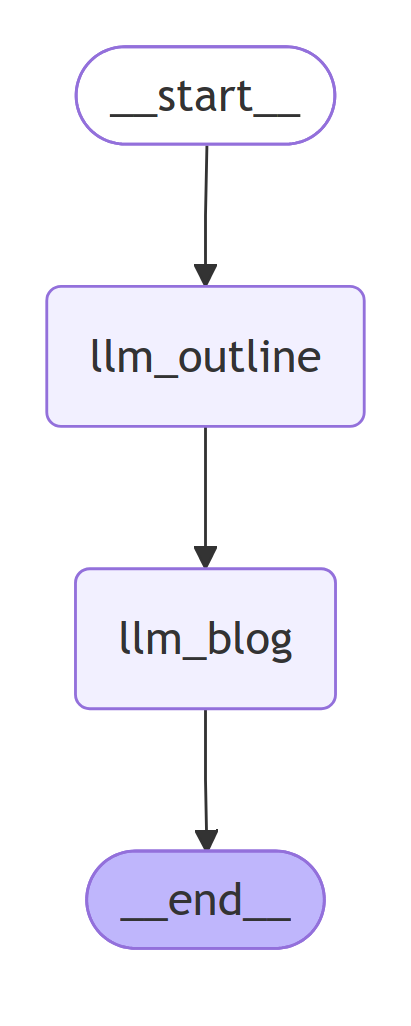

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER))

### 8. Run the code

In [9]:
initial_state = { "topic" : "Motorcycles" }

final_state = workflow.invoke(initial_state)

print(final_state)


{'topic': 'Motorcycles', 'outline': 'This is a vast and incredibly fun topic! Because "motorcycles" can mean anything from technical mechanical deep dives to epic adventure travel, the outline needs to match your **target audience** and your **brand niche**.\n\nTo give you maximum utility, I have provided **four distinct outline styles**. Choose the one that best fits the tone and focus you want for your blog (e.g., Are you a luxury reviewer? A camping adventurer? A brand new rider?).\n\n***\n\n## 🧭 1. The Adventure Travel Blog (The Narrative Focus)\n\n**Goal:** To inspire readers and make them feel like they are on the journey with you. This style sells *experience*, not just motorcycles.\n**Ideal Post Type:** "Trip Reports," "Ultimate Guides," "Destination Deep Dives."\n\n### 📝 Outline Template: "The Epic Journey to [Location]"\n\n**I. The Hook (The Beginning/Setting the Scene)**\n*   **The Teaser:** Start with a powerful sensory description (smell of gasoline, feel of wind, vast emp

In [10]:
print(final_state["outline"])

This is a vast and incredibly fun topic! Because "motorcycles" can mean anything from technical mechanical deep dives to epic adventure travel, the outline needs to match your **target audience** and your **brand niche**.

To give you maximum utility, I have provided **four distinct outline styles**. Choose the one that best fits the tone and focus you want for your blog (e.g., Are you a luxury reviewer? A camping adventurer? A brand new rider?).

***

## 🧭 1. The Adventure Travel Blog (The Narrative Focus)

**Goal:** To inspire readers and make them feel like they are on the journey with you. This style sells *experience*, not just motorcycles.
**Ideal Post Type:** "Trip Reports," "Ultimate Guides," "Destination Deep Dives."

### 📝 Outline Template: "The Epic Journey to [Location]"

**I. The Hook (The Beginning/Setting the Scene)**
*   **The Teaser:** Start with a powerful sensory description (smell of gasoline, feel of wind, vast emptiness).
*   **The Promise:** Introduce the destina

In [11]:
print(final_state["blog"])

***
*(Based on **🧭 1. The Adventure Travel Blog (The Narrative Focus)**)*
***

# Chasing the Horizon: Our Epic Motorcycle Journey Along America's Backbone

**(Featured Image Suggestion: A photo of a motorcycle parked overlooking a dramatic, winding coastal highway at sunset.)**

---

### 🛣️ The Teaser: The Call of the Road

The smell hits you first. It’s a wild, perfect blend: salt brine mixing with high-octane gasoline, underscored by the faint, sweet scent of creosote bush baking under a relentless California sun.

The sound follows—not the aggressive roar of a street bike, but the steady, hypnotic *thrum* of an engine finding its rhythm, weaving a perfect symphony with the rush of wind through your helmet.

There is nothing quite like it. The road, laid out before you like a black ribbon dipped in oil, doesn't just promise a destination; it promises *escape*.

For years, the longing has been an itch—a craving for the vast emptiness and the perfect communion between machine, rider, a